# 02 · Feature engineering

This dataset is already PCA-transformed, which means the original transaction attributes are unavailable. Instead of relying solely on the provided features, I have created additional signals that may help distinguish fraudulent and legitimate behaviour.

1. **Synthetic cardholders** — approximate user identities using clustering.
2. **Velocity** — recent transaction activity around each transaction.
3. **Personal deviation** — how unusual an amount is relative to a cardholder's history.
4. **Cyclic time** — encode time-of-day while preserving daily cycles.
5. **Amount transforms** — log-scaled and bucketed transaction amounts.

> Note: The dataset does not contain user IDs. Synthetic cardholders are approximated by clustering PCA features and are used only for feature engineering experiments.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(os.path.join("..", "src")))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import fraud_utils as fu

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
sns.set_theme(style="whitegrid")
ART = fu.ARTIFACTS_DIR
RNG = np.random.default_rng(42)

In [2]:
df = pd.read_parquet(os.path.join(ART, '01_data.parquet'))
print(df.shape)
df.head(3)

(284807, 33)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V23,V24,V25,V26,V27,V28,Amount,Class,month,is_drift
0,0.0000,-1.3598,-0.0728,2.5363,1.3782,-0.3383,0.4624,0.2396,0.0987,0.3638,...,-0.1105,0.0669,0.1285,-0.1891,0.1336,-0.0211,149.6200,0,1,False
1,0.0000,1.1919,0.2662,0.1665,0.4482,0.0600,-0.0824,-0.0788,0.0851,-0.2554,...,0.1013,-0.3398,0.1672,0.1259,-0.0090,0.0147,2.6900,0,1,False
2,1.0000,-1.3584,-1.3402,1.7732,0.3798,-0.5032,1.8005,0.7915,0.2477,-1.5147,...,0.9094,-0.6893,-0.3276,-0.1391,-0.0554,-0.0598,378.6600,0,1,False


## 1 · Synthetic cardholders
Transactions are clustered using K-Means on the PCA features. Each cluster is treated as a synthetic cardholder, enabling user-level behavioural features despite the absence of real customer IDs.

In [3]:
df = fu.assign_synthetic_cardholders(df, n_cards=300)
print('pseudo-cardholders:', df['card_id'].nunique())
df['card_id'].value_counts().head()

pseudo-cardholders: 300


card_id
297    3439
37     2867
250    2804
115    2631
289    2467
Name: count, dtype: int64

## 2 · Transaction velocity

For each transaction, count how many transactions occurred in the preceding `window` seconds. We sort by `Time` and use `searchsorted`, which is O(n log n) instead of a slow loop.

In [4]:
def velocity(times, window=3600):
    t = np.sort(times.values)
    order = np.argsort(times.values)
    # for each t_i, index of first txn within [t_i - window, t_i]
    left = np.searchsorted(t, t - window, side='left')
    counts_sorted = np.arange(len(t)) - left
    counts = np.empty(len(t), dtype=int)
    counts[order] = counts_sorted
    return counts

df['velocity_1h'] = velocity(df['Time'], window=3600)
df['velocity_10m'] = velocity(df['Time'], window=600)
df[['Time', 'velocity_10m', 'velocity_1h']].describe()

,Time,velocity_10m,velocity_1h
count,"284,807.0000","284,807.0000","284,807.0000"
mean,"94,813.8596","1,223.4396","7,245.3576"
std,"47,488.1460",349.1648,"2,113.9964"
min,0.0000,0.0000,0.0000
25%,"54,201.5000","1,218.0000","7,407.0000"
50%,"84,692.0000","1,327.0000","7,941.0000"
75%,"139,320.5000","1,410.0000","8,391.0000"
max,"172,792.0000","2,240.0000","10,553.0000"


## 3 · Deviation from the cardholder's normal spend

Measure how unusual a transaction amount is relative to a cardholder's typical spending pattern. This captures behaviour that raw transaction amounts may miss.

In [5]:
grp = df.groupby('card_id')['Amount']
card_mean = grp.transform('mean')
card_std = grp.transform('std').replace(0, np.nan)
df['amount_z'] = ((df['Amount'] - card_mean) / card_std).fillna(0.0)
df[['Amount', 'amount_z']].describe()

,Amount,amount_z
count,"284,807.0000","284,807.0000"
mean,88.3496,0.0000
std,250.1201,0.9995
min,0.0000,-2.7758
25%,5.6000,-0.5200
50%,22.0000,-0.3476
75%,77.1650,0.1080
max,"25,691.1600",16.5000


## 4 · Cyclic time-of-day

Encode time-of-day using sine and cosine features so the model recognizes daily cycles and treats midnight as a continuous transition rather than a sharp boundary.

In [6]:
seconds_in_day = df['Time'] % 86400
angle = 2 * np.pi * seconds_in_day / 86400
df['tod_sin'] = np.sin(angle)
df['tod_cos'] = np.cos(angle)
df[['Time', 'tod_sin', 'tod_cos']].head()

,Time,tod_sin,tod_cos
0,0.0000,0.0000,1.0000
1,0.0000,0.0000,1.0000
2,1.0000,0.0001,1.0000
3,1.0000,0.0001,1.0000
4,2.0000,0.0001,1.0000


## 5 · Amount transforms

Transaction amounts are highly skewed. A log transform compresses extreme values, while quantile buckets provide a coarse measure of transaction size.

In [7]:
df['amount_log'] = np.log1p(df['Amount'])
df['amount_bucket'] = pd.qcut(df['Amount'].rank(method='first'),
                              q=5, labels=False)
df[['Amount', 'amount_log', 'amount_bucket']].head()

,Amount,amount_log,amount_bucket
0,149.6200,5.0148,4
1,2.6900,1.3056,0
2,378.6600,5.9393,4
3,123.5000,4.8243,4
4,69.9900,4.2625,3


## Which engineered features actually carry signal?

A quick check of how each engineered feature relates to fraud. Individual correlations are small, but useful features often become more powerful when combined by a model.

velocity_10m    -0.0243
velocity_1h     -0.0229
tod_sin          0.0128
amount_log      -0.0083
amount_bucket   -0.0078
amount_z         0.0070
tod_cos          0.0059
Name: Class, dtype: float64


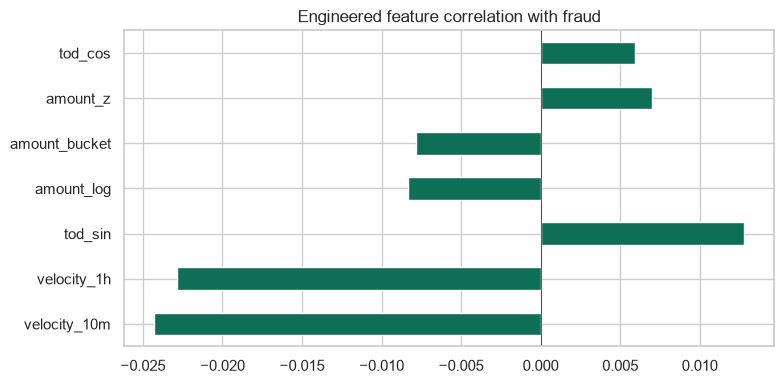

In [8]:
eng = ['velocity_10m', 'velocity_1h', 'amount_z',
       'tod_sin', 'tod_cos', 'amount_log', 'amount_bucket']
corr_class = (df[eng + ['Class']].corr()['Class']
              .drop('Class').sort_values(key=abs, ascending=False))
print(corr_class)

fig, ax = plt.subplots(figsize=(8, 4))
corr_class.plot(kind='barh', ax=ax, color='#0F6E56')
ax.set_title('Engineered feature correlation with fraud')
ax.axvline(0, color='k', lw=.5)
plt.tight_layout(); plt.show()

In [9]:
out = os.path.join(ART, '02_features.parquet')
df.to_parquet(out, index=False)
print('saved', out, df.shape)
print('columns:', list(df.columns))

saved c:\Users\mkpad\OneDrive\Desktop\fraud-detection-research\artifacts\02_features.parquet (284807, 41)
columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class', 'month', 'is_drift', 'card_id', 'velocity_1h', 'velocity_10m', 'amount_z', 'tod_sin', 'tod_cos', 'amount_log', 'amount_bucket']


## Takeaways

- Added behaviour-based features such as transaction velocity and spending deviation that are not directly captured by the PCA features.
- Encoded time-of-day as a cyclic variable so midnight is treated correctly.
- Velocity features showed the strongest individual signal, while the other engineered features may still help when combined by a model.

Next: train and compare multiple models using the same train/test split and preprocessing pipeline.